<a href="https://colab.research.google.com/github/mamezquita/PROYECTO-EEP-LEARNING-NOTICIAS/blob/main/finetuning_bayesiano_colombia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ajuste fino de RoBERTa-BNE con búsqueda bayesiana (Keras Tuner)

**Proyecto Integrador · Deep Learning · 2026-2**

Toma el mismo modelo (RoBERTa-BNE) y el mismo corpus colombiano
(`dataset_politica_colombiana.xlsx`, 3.259 filas) que los notebooks
`Ejecucion_final_colombia_baseline_roberta_bne.ipynb` /
`fake_news_es_baseline.ipynb`, pero reemplaza el **ajuste manual de
hiperparámetros** del artículo de referencia (Blanco-Fernández et al. 2024)
por una **búsqueda bayesiana con Keras Tuner** (`CONFIG["n_trials"]` = 8
intentos), seguida de un **análisis de convergencia** (§16) que verifica si
los mejores hiperparámetros encontrados son una señal real o el resultado
de un intento con suerte.

## Qué cambia respecto al artículo y por qué

El artículo declara explícitamente (Sección 4.2, tras descartar
`GridSearchCV`, `RandomizedSearchCV`, Optuna y Hyperopt por considerarlos
costosos o propensos a pasar por alto combinaciones importantes) que usó
**ajuste manual** de 5 hiperparámetros — tasa de aprendizaje, tamaño de
lote, épocas, tasa de *dropout* y regularización L2 — reportados en su
Tabla 3 para el modelo RoBERTa:

| Hiperparámetro | Valor del artículo (fila RoBERTa) |
|---|---|
| Tasa de aprendizaje | 1×10⁻⁵ |
| Longitud máxima de secuencia | 128 |
| Tamaño de lote | 16 |
| Épocas | 10 |
| Tasa de *dropout* | 0.15 |
| Regularización L2 | 0.001 |
| Semilla | 16 |

Este notebook busca esos mismos 5 hiperparámetros con
`keras_tuner.BayesianOptimization` en vez de a mano, usando los valores del
artículo como **centro del espacio de búsqueda**, no como valores fijos.
Además busca dos hiperparámetros que **el artículo no reporta en
absoluto** (no aparece ni "patience" ni "ReduceLROnPlateau" en ningún lugar
del texto): el factor y la paciencia de reducción de tasa de aprendizaje
sobre meseta, y la paciencia de parada temprana.

Una vez que la búsqueda encuentra su mejor combinación (§15), la §16 la
reentrena varias veces con semillas distintas para comprobar que el
resultado sea reproducible, y no ruido de un solo intento.

**Se mantiene igual que el artículo:** el modelo se ajusta por completo,
**sin congelar ninguna capa** — el artículo lo dice explícitamente ("The
entire model is fine-tuned without freezing any layers"). No hay ningún
hiperparámetro de congelamiento en este notebook porque el artículo tampoco
lo tiene: la tasa de neuronas congeladas es 0 % en ambos casos.

## Por qué TensorFlow/Keras en vez de PyTorch

Los otros notebooks de este repositorio usan PyTorch + HuggingFace
`Trainer`/bucle manual. Keras Tuner es una librería nativa de
TensorFlow/Keras: su patrón `HyperModel.build(hp)` / `HyperModel.fit(hp,
model, ...)` está diseñado y probado contra modelos `tf.keras.Model`. Forzar
Keras Tuner sobre un bucle de entrenamiento en PyTorch es técnicamente
posible pero exige sobrescribir partes internas de la librería que no están
pensadas para eso. Este notebook usa en su lugar
`TFAutoModelForSequenceClassification` de HuggingFace, que **es** un
`tf.keras.Model` y se compila/entrena de forma nativa. Es un cambio de
framework deliberado, limitado a este notebook.

## ⚠️ Nota de honestidad sobre este notebook

El código se escribió y revisó cuidadosamente contra la documentación
oficial de Keras, Keras Tuner y HuggingFace, pero **no pudo probarse de
punta a punta antes de entregarlo**: el entorno donde se escribió no tiene
TensorFlow instalable (incompatibilidad de versión de Python), así que no
hubo forma de ejecutarlo ahí. Por eso la primera celda de ejecución real
(§12) es una **prueba de humo** deliberadamente barata (1 recorte, 1 época,
~30 filas) que tiene que completarse sin error antes de que el notebook siga
adelante — si algo del cableado Keras Tuner/TensorFlow/HuggingFace está mal,
se sabrá en menos de un minuto, no después de una búsqueda larga.

## Qué necesitas para correr esto

1. Abrir este notebook en Google Colab (usa el badge de arriba).
2. **Activar GPU**: Entorno de ejecución → Cambiar tipo de entorno de
   ejecución → GPU (T4 gratis alcanza).
3. Ejecutar todas las celdas en orden. La §2 te va a pedir que subas
   `dataset_politica_colombiana.xlsx` (el que está en este repositorio) —
   un cuadro de diálogo de subida de archivos aparecerá automáticamente.
4. Esperar. La §13 (calibración) te dirá cuánto va a tardar la búsqueda
   completa (§14, 8 intentos) con el hardware que Colab te haya asignado,
   antes de lanzarla. La §16 (análisis de convergencia) entrena algunos
   modelos adicionales después de la búsqueda, así que toma tiempo extra.


## §1 · Instalación e importaciones

In [1]:
import sys

# TF_USE_LEGACY_KERAS solo funciona si se fija ANTES de que tensorflow se
# importe por primera vez en este proceso de kernel. Si ya estaba
# importado (por ejemplo por haber corrido esta celda antes sin reiniciar
# el entorno de ejecucion), fijarlo ahora ya no sirve de nada -- se avisa
# explicitamente en vez de fallar mas abajo con un error dificil de
# entender.
assert "tensorflow" not in sys.modules, (
    "tensorflow ya estaba importado en este kernel antes de correr esta "
    "celda, asi que TF_USE_LEGACY_KERAS no puede tomar efecto aqui. "
    "Anda a Entorno de ejecucion -> Reiniciar entorno de ejecucion, y "
    "corre esta celda primero, antes que cualquier otra."
)

# transformers >=5.0 (26 ene 2026) eliminó por completo el soporte TF/Flax:
# TFAutoModelForSequenceClassification y toda la familia TF* ya no existen ahí.
# Se fija <5.0 para quedarnos con la última serie 4.x que sí trae clases TF.
#
# OJO: sin el extra "[tf]". Ese extra fija tensorflow<2.16,>2.9 -- una
# restricción de antes de que existiera TF 2.16/Keras 3, hoy obsoleta.
# Con Colab trayendo TensorFlow >=2.16 preinstalado, pedir "[tf]" produce
# un conflicto irresoluble entre esa versión vieja exigida y la ya
# instalada. transformers no necesita el extra para funcionar con TF: solo
# necesita poder importarlo en tiempo de ejecución, no que esté declarado
# como dependencia fija.
#
# keras-tuner se fija en 1.3.5 (la última versión antes de que agregara
# soporte multi-backend para Keras 3). Desde la 1.4.0, keras_tuner decide
# internamente si usar Keras 3 o tf.keras mirando la versión del paquete
# "keras" independiente (no tf.keras/TF_USE_LEGACY_KERAS) -- y como ese
# paquete siempre es 3.x junto a TensorFlow >=2.16, keras_tuner valida los
# modelos contra keras.Model (Keras 3), mientras que nuestro modelo (por
# el shim tf-keras de arriba) es tf_keras.Model. Son clases distintas: el
# isinstance check de keras_tuner falla con FatalTypeError aunque el
# modelo sea perfectamente válido. keras-tuner 1.3.5 es anterior a esa
# rama de código: usa siempre "from tensorflow import keras", que sí seguye
# a TF_USE_LEGACY_KERAS.
!pip install -q "transformers>=4.44,<5.0" "tf-keras" "keras-tuner==1.3.5" "huggingface_hub>=0.24" openpyxl scikit-learn

# Colab trae TensorFlow >=2.16, cuyo tf.keras por defecto es Keras 3.
# transformers todavia no soporta Keras 3 para sus modelos TF, asi que hay
# que forzar el shim de compatibilidad (paquete tf-keras) ANTES de importar
# tensorflow -- si se hace despues, no tiene efecto.
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import json
import time
import random
import re
import unicodedata
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# tensorflow se importa y se valida el modo legado ANTES de tocar
# keras_tuner o transformers, para que si algo salio mal (por ejemplo que
# tf-keras no haya quedado instalado) el error salte aca, con un mensaje
# claro, y no como un ImportError críptico varias líneas más abajo al
# intentar importar TFAutoModelForSequenceClassification.
import tensorflow as tf

print("tensorflow    :", tf.__version__)

# tf.keras (via el shim tf-keras) no siempre expone __version__ -- el
# nombre del modulo subyacente es la forma confiable de distinguir Keras 2
# legado ("tf_keras...") de Keras 3 ("keras...").
_keras_modulo = tf.keras.__name__
_es_legado = _keras_modulo.startswith("tf_keras")
print("tf.keras modulo:", _keras_modulo, "(legado)" if _es_legado else "(Keras 3 -- NO esperado)")

assert _es_legado, (
    f"tf.keras esta resolviendo a '{_keras_modulo}', o sea Keras 3, no al modo "
    "legado -- probablemente porque el paquete tf-keras no se instalo bien. "
    "Reinicia el entorno de ejecucion (Entorno de ejecucion -> Reiniciar "
    "entorno de ejecucion) y vuelve a correr esta celda primero."
)

import keras_tuner as kt

import sklearn
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, confusion_matrix, classification_report,
)

import transformers

_transformers_mayor = int(transformers.__version__.split(".")[0])
assert _transformers_mayor < 5, (
    f"transformers {transformers.__version__} no trae clases TF "
    "(TFAutoModelForSequenceClassification y compania se eliminaron en la serie "
    "5.x). El pip install de arriba deberia haber fijado <5.0 -- revisa que no "
    "haya quedado una version 5.x cacheada de una instalacion anterior en este "
    "entorno de Colab."
)

from transformers import AutoTokenizer, AutoConfig, TFAutoModelForSequenceClassification
from huggingface_hub import list_repo_files, model_info

print("keras_tuner   :", kt.__version__)
print("transformers  :", transformers.__version__)
print("scikit-learn  :", sklearn.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU           :", gpus if gpus else "NO DISPONIBLE (activa GPU en Entorno de ejecucion -> Cambiar tipo)")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 55.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
tensorflow    : 2.20.0
tf.keras modulo: tf_keras.api._v2.keras (legado)
keras_tuner   : 1.3.5
transformers  : 4.57.6
scikit-learn  : 1.6.1
GPU           : [PhysicalDevice(name='/physical_device:GPU:0',

## §2 · Subir el corpus

Sube `dataset_politica_colombiana.xlsx` (el archivo de este repositorio,
3.259 filas). Si ya existe en el directorio de trabajo de Colab (por
ejemplo, porque montaste Google Drive), esta celda lo detecta y no vuelve a
pedirlo.


In [2]:
RUTA_XLSX = "dataset_politica_colombiana.xlsx"

if not os.path.exists(RUTA_XLSX):
    try:
        from google.colab import files
        print("Sube 'dataset_politica_colombiana.xlsx':")
        subido = files.upload()
        if RUTA_XLSX not in subido:
            # el usuario pudo subir con otro nombre; usar el primer .xlsx que llegue
            candidatos = [n for n in subido if n.lower().endswith(".xlsx")]
            if candidatos:
                os.rename(candidatos[0], RUTA_XLSX)
    except ImportError:
        raise FileNotFoundError(
            f"No se encontró '{RUTA_XLSX}' y esto no parece ser Colab "
            "(no se pudo importar google.colab.files). Copia el archivo "
            "al directorio de trabajo manualmente."
        )

assert os.path.exists(RUTA_XLSX), f"'{RUTA_XLSX}' sigue sin existir tras el intento de subida."
print(f"✓ {RUTA_XLSX} listo ({os.path.getsize(RUTA_XLSX)/1024:.0f} KB)")


Sube 'dataset_politica_colombiana.xlsx':


Saving dataset_politica_colombiana.xlsx to dataset_politica_colombiana.xlsx
✓ dataset_politica_colombiana.xlsx listo (537 KB)


## §3 · Configuración

Los 5 hiperparámetros de la Tabla 3 del artículo (aprendizaje, lote,
*dropout*, L2, épocas) definen aquí su **centro de búsqueda**, no un valor
fijo — el rango real de cada uno se define más abajo, en el `HyperModel`
(§7), usando estos centros como referencia explícita en los comentarios.

Las épocas se manejan distinto: el artículo fija 10 para un corpus de
~46.000 filas; el nuestro tiene 3.259. En vez de fijar 10 igual, se pone un
**techo** más alto y se deja que la parada temprana (con paciencia también
buscada por Keras Tuner) decida la duración real de cada intento — es más
estándar y no desperdicia presupuesto de búsqueda entrenando una
configuración mala hasta el final.


In [3]:
CONFIG = {
    # ---------- DATOS ----------
    "ruta_xlsx": "dataset_politica_colombiana.xlsx",
    "col_label": "label",
    "col_titulo": "title",
    "col_descripcion": "description",
    "col_fecha": "date",
    "campos_texto": ["title", "description"],
    "etiquetas": {"0": "falsa", "1": "real"},

    # ---------- PARTICIÓN (mismo criterio que los otros notebooks) ----------
    "proporciones": [0.70, 0.15, 0.15],   # train / val / test
    "agrupar_variantes": True,             # anti-fuga: ver §6

    # ---------- MODELO ----------
    # Mismo orden y mismos candidatos que fake_news_es_baseline.ipynb, para que
    # ambos notebooks resuelvan al mismo modelo si están en el mismo entorno.
    # Verificado (sept. 2026): PlanTL-GOB-ES/roberta-base-bne quedó vaciado
    # (solo README, apunta a BSC-LT); BSC-LT/roberta-base-bne y
    # BSC-TeMU/roberta-base-bne ahora exigen autenticación en el Hub (HTTP 401
    # sin token) — ver el intento de login con HF_TOKEN en §8. IsGarrido/roberta-base-bne
    # es un espejo comunitario público que sí resuelve sin token, aunque solo
    # trae pesos en formato PyTorch (ver from_pt en §11).
    "modelo_candidatos": [
        "PlanTL-GOB-ES/roberta-base-bne",   # repositorio del artículo (hoy vaciado)
        "BSC-LT/roberta-base-bne",          # mismo modelo, mismo grupo (BSC), otro namespace
        "BSC-TeMU/roberta-base-bne",        # namespace anterior de BSC-LT
        "IsGarrido/roberta-base-bne",       # espejo comunitario público, sin auth
    ],
    "modelo_respaldo": "bertin-project/bertin-roberta-base-spanish",  # RoBERTa en español, otro corpus de preentrenamiento
    "max_seq_length": 128,   # Tabla 3, fila RoBERTa — FIJO, no se busca

    # ---------- CENTROS DE BÚSQUEDA (Tabla 3 del artículo) ----------
    # Usados como referencia en los rangos de kt.HyperParameters en §7.
    "centro_learning_rate": 1e-5,
    "centro_batch_size": 16,
    "centro_dropout": 0.15,
    "centro_l2": 0.001,
    "centro_epocas": 10,   # referencia; el techo real es "epocas_techo" abajo

    # ---------- BÚSQUEDA BAYESIANA ----------
    "n_trials": 8,
    "epocas_techo": 15,     # techo duro; la parada temprana decide la duración real
    "objetivo": "val_f1_macro",   # F1-macro, no accuracy — ver nota en §7
    "objetivo_direccion": "max",
    "directorio_busqueda": "kt_busqueda_bayesiana",
    "nombre_proyecto": "roberta_bne_colombia",

    # ---------- REPRODUCIBILIDAD ----------
    "seed": 16,   # la semilla que reporta el artículo para RoBERTa (Tabla 3)
}

print(json.dumps(CONFIG, indent=2, ensure_ascii=False))


{
  "ruta_xlsx": "dataset_politica_colombiana.xlsx",
  "col_label": "label",
  "col_titulo": "title",
  "col_descripcion": "description",
  "col_fecha": "date",
  "campos_texto": [
    "title",
    "description"
  ],
  "etiquetas": {
    "0": "falsa",
    "1": "real"
  },
  "proporciones": [
    0.7,
    0.15,
    0.15
  ],
  "agrupar_variantes": true,
  "modelo_candidatos": [
    "PlanTL-GOB-ES/roberta-base-bne",
    "BSC-LT/roberta-base-bne",
    "BSC-TeMU/roberta-base-bne",
    "IsGarrido/roberta-base-bne"
  ],
  "modelo_respaldo": "bertin-project/bertin-roberta-base-spanish",
  "max_seq_length": 128,
  "centro_learning_rate": 1e-05,
  "centro_batch_size": 16,
  "centro_dropout": 0.15,
  "centro_l2": 0.001,
  "centro_epocas": 10,
  "n_trials": 8,
  "epocas_techo": 15,
  "objetivo": "val_f1_macro",
  "objetivo_direccion": "max",
  "directorio_busqueda": "kt_busqueda_bayesiana",
  "nombre_proyecto": "roberta_bne_colombia",
  "seed": 16
}


## §4 · Reproducibilidad

In [4]:
def fijar_semillas(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


fijar_semillas(CONFIG["seed"])
print(f"Semilla fijada en {CONFIG['seed']} (random, numpy, tensorflow).")


Semilla fijada en 16 (random, numpy, tensorflow).


## §5 · Carga y limpieza

Misma lógica que en `fake_news_es_baseline.ipynb`: valida columnas,
construye el campo `texto` (título + descripción), descarta filas sin texto
o con etiqueta inválida, parsea fechas, elimina duplicados exactos.


In [5]:
def cargar_y_limpiar(ruta, cfg):
    col_l, col_t = cfg["col_label"], cfg["col_titulo"]
    col_d, col_f = cfg["col_descripcion"], cfg["col_fecha"]

    df = pd.read_excel(ruta)
    print(f"Filas leídas: {len(df):,}")

    faltantes = {col_l, col_t, col_d} - set(df.columns)
    if faltantes:
        raise ValueError(f"Faltan columnas: {faltantes}. Columnas presentes: {df.columns.tolist()}")

    df = df.copy()
    for c in [col_t, col_d]:
        df[c] = df[c].fillna("").astype(str).str.strip()

    partes = [df[c] for c in cfg["campos_texto"] if c in df.columns]
    df["texto"] = partes[0]
    for p in partes[1:]:
        df["texto"] = (df["texto"] + ". " + p).str.replace(r"\.\s*\.", ".", regex=True)
    df["texto"] = df["texto"].str.strip()

    n0 = len(df)
    df = df[df["texto"].str.len() > 0]

    df[col_l] = pd.to_numeric(df[col_l], errors="coerce")
    if df[col_l].isna().all():
        # el label vino como texto "TRUE"/"FALSE" en vez de 0/1
        mapa = {"TRUE": 1, "FALSE": 0, "REAL": 1, "FALSA": 0}
        df[col_l] = df[cfg["col_label"]].astype(str).str.upper().map(mapa)
    df = df[df[col_l].isin([0, 1])]
    df[col_l] = df[col_l].astype(int)
    print(f"Descartadas por texto vacío o etiqueta inválida: {n0 - len(df):,}")

    if col_f in df.columns:
        df[col_f] = pd.to_datetime(df[col_f], errors="coerce", dayfirst=True)

    n1 = len(df)
    df = df.drop_duplicates(subset=["texto", col_l])
    print(f"Duplicados exactos eliminados: {n1 - len(df):,}")

    df = df.reset_index(drop=True)
    df["row_id"] = np.arange(len(df))
    return df


df = cargar_y_limpiar(CONFIG["ruta_xlsx"], CONFIG)
print(f"\nFilas finales: {len(df):,}")
print(df[CONFIG["col_label"]].value_counts())


Filas leídas: 3,259
Descartadas por texto vacío o etiqueta inválida: 0
Duplicados exactos eliminados: 0

Filas finales: 3,259
label
1    1633
0    1626
Name: count, dtype: int64


## §6 · Agrupamiento anti-fuga

Idéntico al de los otros notebooks: *union-find* sobre título y descripción
normalizados, para que ninguna variante casi-idéntica de una misma noticia
quede repartida entre entrenamiento y prueba.


In [6]:
def normalizar_texto(s: str) -> str:
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode()
    s = s.lower()
    s = re.sub(r"[^a-z0-9 ]", " ", s)
    return re.sub(r"\s+", " ", s).strip()


def asignar_grupos(df, cfg):
    if not cfg["agrupar_variantes"]:
        return np.arange(len(df))

    parent = {}

    def find(x):
        parent.setdefault(x, x)
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb

    tits = df[cfg["col_titulo"]].map(normalizar_texto).values
    descs = df[cfg["col_descripcion"]].map(normalizar_texto).values

    for i in range(len(df)):
        if tits[i]:
            union(("row", i), ("tit", tits[i]))
        if descs[i]:
            union(("row", i), ("des", descs[i]))

    raices = [find(("row", i)) for i in range(len(df))]
    codigo = {r: k for k, r in enumerate(dict.fromkeys(raices))}
    return np.array([codigo[r] for r in raices])


df["grupo"] = asignar_grupos(df, CONFIG)
print(f"Grupos únicos: {df['grupo'].nunique():,} sobre {len(df):,} filas")


Grupos únicos: 3,238 sobre 3,259 filas


## §7 · Partición train / validación / prueba

In [7]:
def _corte_estratificado_por_grupo(y, grupos, fraccion, seed):
    n_splits = max(2, int(round(1 / fraccion)))
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    idx_resto, idx_sel = next(sgkf.split(np.zeros(len(y)), y, groups=grupos))
    return idx_resto, idx_sel


def particionar(df, cfg):
    p_train, p_val, p_test = cfg["proporciones"]
    y = df[cfg["col_label"]].values
    g = df["grupo"].values
    splits = pd.Series("train", index=df.index)

    idx_resto, idx_test = _corte_estratificado_por_grupo(y, g, p_test, cfg["seed"])
    frac_val = p_val / (p_train + p_val)
    idx_train_rel, idx_val_rel = _corte_estratificado_por_grupo(
        y[idx_resto], g[idx_resto], frac_val, cfg["seed"]
    )
    splits.iloc[idx_resto[idx_val_rel]] = "val"
    splits.iloc[idx_test] = "test"
    return splits


df["split"] = particionar(df, CONFIG)
tabla = pd.crosstab(df["split"], df[CONFIG["col_label"]])
tabla["total"] = tabla.sum(axis=1)
print(tabla.loc[["train", "val", "test"]])

n_fuga = int((df.groupby("grupo")["split"].nunique() > 1).sum())
print(f"\nGrupos repartidos entre splits (fuga): {n_fuga}")
print("  ✓ Sin fuga." if n_fuga == 0 else f"  ⚠️ {n_fuga} grupos partidos.")


label     0     1  total
split                   
train  1187  1171   2358
val     221   231    452
test    218   231    449

Grupos repartidos entre splits (fuga): 0
  ✓ Sin fuga.


## §8 · Resolución del modelo preentrenado

Misma lógica de resolución que los notebooks en PyTorch: prueba varios
repositorios candidatos en orden, usa el primero con pesos descargables, y
registra el commit exacto usado para reproducibilidad.

Primero intenta autenticarse con Hugging Face Hub usando el secreto
`HF_TOKEN` de Colab, si existe (Herramientas → Datos secretos). Es
**opcional**: sin token, los repositorios que ahora exigen autenticación
(`BSC-LT/roberta-base-bne`, `BSC-TeMU/roberta-base-bne`) se descartan
automáticamente y la resolución sigue con el siguiente candidato público.


In [8]:
try:
    from google.colab import userdata
    _hf_token = userdata.get("HF_TOKEN")
except Exception:
    _hf_token = None

if _hf_token:
    from huggingface_hub import login
    login(token=_hf_token, add_to_git_credential=False)
    print("Autenticado en Hugging Face Hub con el secreto HF_TOKEN de Colab.")
else:
    print("Sin HF_TOKEN en los secretos de Colab: se usan solo repositorios "
          "públicos. (El UserWarning de huggingface_hub sobre esto es "
          "informativo, no bloquea nada.)")

ARCHIVOS_PESOS = ("model.safetensors", "pytorch_model.bin", "tf_model.h5",
                  "model.safetensors.index.json", "pytorch_model.bin.index.json")

FICHA_OFICIAL = {
    "model_type": "roberta", "vocab_size": 50262, "num_hidden_layers": 12,
    "hidden_size": 768, "num_attention_heads": 12, "max_position_embeddings": 514,
}


def repo_utilizable(repo_id):
    try:
        archivos = set(list_repo_files(repo_id))
    except Exception as e:
        return False, type(e).__name__, None
    if "config.json" not in archivos:
        return False, "sin config.json (deprecado)", None
    if not any(a in archivos for a in ARCHIVOS_PESOS):
        return False, "sin archivos de pesos", None
    try:
        sha = model_info(repo_id).sha
    except Exception:
        sha = None
    return True, "ok", sha


def resolver_modelo(cfg):
    candidatos = list(cfg["modelo_candidatos"]) + [cfg["modelo_respaldo"]]
    print("Comprobando repositorios candidatos:\n")
    for repo in candidatos:
        ok, motivo, sha = repo_utilizable(repo)
        print(f"  {'✓ USABLE' if ok else '✗ ' + motivo:<32} {repo}")
        if ok:
            return repo, sha
    raise RuntimeError("Ningún repositorio candidato tiene pesos descargables.")


MODELO, MODELO_SHA = resolver_modelo(CONFIG)
print(f"\n→ Modelo resuelto: {MODELO}  (commit {MODELO_SHA})")

# Nota: si el repositorio resuelto solo trae pesos de PyTorch (como
# IsGarrido/roberta-base-bne), el HyperModel de §11 reintenta la carga con
# from_pt=True automáticamente -- ver el try/except ahí.


Sin HF_TOKEN en los secretos de Colab: se usan solo repositorios públicos. (El UserWarning de huggingface_hub sobre esto es informativo, no bloquea nada.)
Comprobando repositorios candidatos:



/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


  ✗ sin config.json (deprecado)    PlanTL-GOB-ES/roberta-base-bne
  ✗ RepositoryNotFoundError        BSC-LT/roberta-base-bne
  ✗ RepositoryNotFoundError        BSC-TeMU/roberta-base-bne
  ✓ USABLE                         IsGarrido/roberta-base-bne

→ Modelo resuelto: IsGarrido/roberta-base-bne  (commit 3d54a71ddc029cc1f8dd604e3b7bc0da0e2f7cd9)


## §9 · Tokenización

Longitud máxima fija en 128 (Tabla 3 del artículo) — **no** es un
hiperparámetro de búsqueda. Se tokeniza una sola vez, fuera del bucle de
búsqueda: los arreglos NumPy resultantes se reutilizan en cada intento.


In [9]:
tokenizer = AutoTokenizer.from_pretrained(MODELO)
print(f"Tokenizador: {tokenizer.__class__.__name__}  |  vocabulario: {tokenizer.vocab_size:,}")


def tokenizar_split(df, split, cfg):
    sub = df[df["split"] == split]
    enc = tokenizer(
        list(sub["texto"].values),
        truncation=True, padding="max_length",
        max_length=cfg["max_seq_length"], return_tensors="np",
    )
    y = sub[cfg["col_label"]].values.astype(np.int32)
    return {"input_ids": enc["input_ids"], "attention_mask": enc["attention_mask"]}, y


X_train, y_train = tokenizar_split(df, "train", CONFIG)
X_val, y_val = tokenizar_split(df, "val", CONFIG)
X_test, y_test = tokenizar_split(df, "test", CONFIG)

print(f"train {len(y_train):,} | val {len(y_val):,} | test {len(y_test):,}")


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/957 [00:00<?, ?B/s]

Tokenizador: RobertaTokenizerFast  |  vocabulario: 50,262
train 2,358 | val 452 | test 449


## §10 · Métrica F1-macro por época

Keras no trae F1-macro incorporado. Este *callback* calcula las
predicciones sobre validación al final de cada época y escribe
`logs["val_f1_macro"]` para que tanto `ReduceLROnPlateau`, `EarlyStopping`
como el propio Keras Tuner puedan monitorearlo — por eso va **primero** en
la lista de *callbacks* (§11): los demás necesitan leer el valor que este
escribe en el mismo `logs` del mismo final de época.

**Por qué F1-macro y no accuracy como objetivo.** El artículo optimiza
accuracy. El notebook base de este proyecto (`fake_news_es_baseline.ipynb`,
§7) argumenta en contra de esa elección porque **el costo de los dos tipos
de error no es simétrico**: no cuesta lo mismo dejar pasar una noticia
falsa (falso negativo) que marcar como falsa una noticia real (falso
positivo). Accuracy pesa ambos errores por igual y por eso puede esconder
un modelo con un desempeño muy distinto entre las dos clases.

Ojo: esa misma justificación en `fake_news_es_baseline.ipynb` también
menciona el desbalance de clases como razón adicional, pero eso **no
aplica al corpus actual** — tras la ampliación con noticias reales, quedó
en 1.633 reales / 1.626 falsas (prácticamente 50/50). La razón que sigue
vigente acá es solo la del costo asimétrico del error, no el desbalance.
Este notebook usa F1-macro por esa razón, y por consistencia con el resto
del proyecto (mismo criterio de evaluación en los tres notebooks). Si se
prefiere replicar la métrica exacta del artículo, cambiar
`CONFIG["objetivo"]` a `"val_accuracy"` y ajustar el callback de abajo.


In [10]:
def a_lista(x_dict):
    """{"input_ids":..., "attention_mask":...} -> [input_ids, attention_mask],
    el orden que esperan las capas Input del modelo funcional de §11.
    Centralizado acá para no repetir la conversión en cada llamada a
    .fit()/.predict() y evitar que alguna quede con el formato viejo."""
    return [x_dict["input_ids"], x_dict["attention_mask"]]


class F1MacroCallback(tf.keras.callbacks.Callback):
    def __init__(self, x_val, y_val, batch_size=32):
        super().__init__()
        self.x_val = a_lista(x_val)
        self.y_val = y_val
        self.batch_size = batch_size

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        logits = self.model.predict(self.x_val, batch_size=self.batch_size, verbose=0)
        y_pred = np.argmax(np.asarray(logits), axis=-1)
        logs["val_f1_macro"] = float(f1_score(self.y_val, y_pred, average="macro", zero_division=0))
        logs["val_mcc"] = float(matthews_corrcoef(self.y_val, y_pred))


print("F1MacroCallback listo.")


F1MacroCallback listo.


## §11 · `HyperModel`: qué se busca y qué queda fijo

- `build(hp)`: arma el modelo — aprendizaje, *dropout* y L2 vienen de `hp`,
  centrados en los valores de la Tabla 3 del artículo. **Ninguna capa se
  congela** (`backbone.trainable = True`, igual que el artículo).

  El cuerpo de HuggingFace (`TFAutoModelForSequenceClassification`) se
  envuelve en un modelo funcional de Keras explícito, cuya única salida es
  el tensor de logits. Es deliberado: los modelos de HuggingFace en TF
  pueden calcular su propia pérdida internamente si se les pasan las
  etiquetas de cierta forma, pero ese comportamiento automático no se pudo
  verificar en este entorno (ver "Nota de honestidad" al inicio del notebook).
  Envolver el modelo así y usar una función
  de pérdida estándar de Keras (`SparseCategoricalCrossentropy`) es el
  patrón más simple y mejor documentado de la API funcional de Keras — con
  menos superficie para un comportamiento inesperado que no se pueda probar
  de antemano.
- `fit(hp, model, ...)`: tamaño de lote (Tabla 3) y los dos hiperparámetros
  que el artículo no reporta (reducción de tasa de aprendizaje y paciencia
  de parada temprana) se deciden aquí.


In [11]:
class RobertaBNEHyperModel(kt.HyperModel):
    def __init__(self, modelo_id, cfg):
        self.modelo_id = modelo_id
        self.cfg = cfg

    def build(self, hp):
        c = self.cfg
        lr = hp.Float("learning_rate", 5e-6, 5e-5, sampling="log", default=c["centro_learning_rate"])
        dropout = hp.Float("dropout", 0.05, 0.30, default=c["centro_dropout"])
        l2 = hp.Float("weight_decay", 1e-4, 1e-2, sampling="log", default=c["centro_l2"])

        config = AutoConfig.from_pretrained(
            self.modelo_id, num_labels=2,
            hidden_dropout_prob=dropout, attention_probs_dropout_prob=dropout,
            classifier_dropout=dropout,
            id2label={0: "falsa", 1: "real"}, label2id={"falsa": 0, "real": 1},
        )
        try:
            backbone = TFAutoModelForSequenceClassification.from_pretrained(
                self.modelo_id, config=config
            )
        except (OSError, EnvironmentError):
            # El repositorio no trae pesos nativos de TF (tf_model.h5 /
            # model.safetensors guardado desde TF) -- típico de espejos
            # comunitarios como IsGarrido/roberta-base-bne, que solo traen
            # pytorch_model.bin. from_pt=True los convierte al vuelo.
            backbone = TFAutoModelForSequenceClassification.from_pretrained(
                self.modelo_id, config=config, from_pt=True
            )
        backbone.trainable = True   # ajuste fino completo -- sin congelar nada, igual que el articulo

        max_len = c["max_seq_length"]
        entrada_ids = tf.keras.Input(shape=(max_len,), dtype=tf.int32, name="input_ids")
        entrada_mask = tf.keras.Input(shape=(max_len,), dtype=tf.int32, name="attention_mask")
        salida = backbone(input_ids=entrada_ids, attention_mask=entrada_mask)
        logits = salida.logits

        modelo = tf.keras.Model(inputs=[entrada_ids, entrada_mask], outputs=logits)

        optimizador = tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=l2)
        modelo.compile(
            optimizer=optimizador,
            loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            metrics=["accuracy"],
        )
        return modelo

    def fit(self, hp, model, x, y, validation_data, **kwargs):
        c = self.cfg
        batch_size = hp.Choice("batch_size", [8, 16, 32], default=c["centro_batch_size"])
        factor_reduccion = hp.Float("lr_reduce_factor", 0.1, 0.5, default=0.3)
        paciencia_reduccion = hp.Int("lr_reduce_patience", 1, 3, default=1)
        paciencia_parada = hp.Int("early_stopping_patience", 2, 6, default=3)

        x_val, y_val = validation_data
        callbacks = [
            F1MacroCallback(x_val, y_val, batch_size=max(32, batch_size * 2)),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_f1_macro", mode="max",
                factor=factor_reduccion, patience=paciencia_reduccion, min_lr=1e-7,
            ),
            tf.keras.callbacks.EarlyStopping(
                monitor="val_f1_macro", mode="max",
                patience=paciencia_parada, restore_best_weights=True,
            ),
        ] + kwargs.pop("callbacks", [])

        return model.fit(
            a_lista(x), y, batch_size=batch_size, callbacks=callbacks, **kwargs
        )


hypermodel = RobertaBNEHyperModel(MODELO, CONFIG)
print("HyperModel listo.")


HyperModel listo.


## §12 · Prueba de humo

Antes de gastar tiempo real de GPU: 1 intento, 1 época, ~30 filas. Solo
verifica que el cableado Keras Tuner + TensorFlow + HuggingFace no esté roto
— no dice nada sobre calidad del modelo. Si esta celda falla, el problema
está en el código de arriba, no en la búsqueda bayesiana en sí.


In [12]:
def _submuestra(X, y, n):
    idx = np.random.RandomState(CONFIG["seed"]).choice(len(y), size=min(n, len(y)), replace=False)
    return {k: v[idx] for k, v in X.items()}, y[idx]


print("Ejecutando prueba de humo (1 intento, 1 época, ~30 filas)...\n")

Xs_train, ys_train = _submuestra(X_train, y_train, 30)
Xs_val, ys_val = _submuestra(X_val, y_val, 20)

_t0 = time.time()
_hp_humo = kt.HyperParameters()   # misma instancia para build() y fit(), como hace Keras Tuner en un trial real
modelo_prueba = hypermodel.build(_hp_humo)
hypermodel.fit(
    _hp_humo, modelo_prueba,
    Xs_train, ys_train, validation_data=(Xs_val, ys_val),
    epochs=1, verbose=0,
)
_t1 = time.time()

del modelo_prueba
tf.keras.backend.clear_session()

print(f"✓ Prueba de humo completada en {_t1 - _t0:.1f}s. El cableado funciona.")
print("  Si llegaste hasta aquí sin error, es seguro continuar con la calibración real (§13).")


Ejecutando prueba de humo (1 intento, 1 época, ~30 filas)...



config.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaForSequenceClassification: ['roberta.embeddings.position_ids']
- This IS expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFRobertaForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.dense.weight', 'classifie

✓ Prueba de humo completada en 121.3s. El cableado funciona.
  Si llegaste hasta aquí sin error, es seguro continuar con la calibración real (§13).


## §13 · Calibración con datos reales

Un intento completo (valores centrales de la Tabla 3, 1 época, datos reales
— no la submuestra de humo) para medir el tiempo real por época en el
hardware que Colab te haya asignado, y estimar cuánto tomará la búsqueda
completa de `CONFIG["n_trials"]` intentos **antes** de lanzarla.


In [13]:
print("Calibrando con 1 época sobre los datos reales...\n")

_hp_central = kt.HyperParameters()
_t0 = time.time()
_modelo_calib = hypermodel.build(_hp_central)
hypermodel.fit(
    _hp_central, _modelo_calib,
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=1, verbose=1,
)
_segundos_por_epoca = time.time() - _t0

del _modelo_calib
tf.keras.backend.clear_session()

# Estimación: techo de épocas asumido ~50-60% recorrido antes de que la
# parada temprana intervenga (supuesto razonable, no medido) + tiempo de
# carga del modelo por intento.
_epocas_estimadas_por_intento = max(3, int(CONFIG["epocas_techo"] * 0.55))
_segundos_por_intento = _segundos_por_epoca * _epocas_estimadas_por_intento
_segundos_totales = _segundos_por_intento * CONFIG["n_trials"]

print(f"\n✓ Calibración: {_segundos_por_epoca:.1f}s/época medidos en este hardware.")
print(f"  Estimación (supone ~{_epocas_estimadas_por_intento} épocas/intento antes de parada temprana):")
print(f"    ≈ {_segundos_por_intento/60:.1f} min/intento")
print(f"    ≈ {_segundos_totales/60:.0f} min ({_segundos_totales/3600:.1f} h) para los {CONFIG['n_trials']} intentos")
print("\n  Esto es una estimación, no una garantía — la parada temprana real")
print("  puede converger antes o después de lo supuesto aquí. Si el número")
print("  te parece demasiado alto, reduce CONFIG['n_trials'] o CONFIG['epocas_techo']")
print("  y vuelve a correr desde §3.")


Calibrando con 1 época sobre los datos reales...



Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaForSequenceClassification: ['roberta.embeddings.position_ids']
- This IS expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFRobertaForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predicti

148/148 [==============================] - 135s 560ms/step - loss: 0.6954 - accuracy: 0.4996 - val_f1_macro: 0.3284 - val_mcc: 0.0000e+00 - lr: 1.0000e-05

✓ Calibración: 139.8s/época medidos en este hardware.
  Estimación (supone ~8 épocas/intento antes de parada temprana):
    ≈ 18.6 min/intento
    ≈ 149 min (2.5 h) para los 8 intentos

  Esto es una estimación, no una garantía — la parada temprana real
  puede converger antes o después de lo supuesto aquí. Si el número
  te parece demasiado alto, reduce CONFIG['n_trials'] o CONFIG['epocas_techo']
  y vuelve a correr desde §3.


## §14 · Búsqueda bayesiana

Lanza la búsqueda completa: `CONFIG["n_trials"]` intentos. Cada intento se
entrena y evalúa una vez sobre **validación**; el conjunto de **prueba** no
se toca hasta la §17.

In [14]:
tuner = kt.BayesianOptimization(
    hypermodel=hypermodel,
    objective=kt.Objective(CONFIG["objetivo"], direction=CONFIG["objetivo_direccion"]),
    max_trials=CONFIG["n_trials"],
    seed=CONFIG["seed"],
    directory=CONFIG["directorio_busqueda"],
    project_name=CONFIG["nombre_proyecto"],
    overwrite=True,
)

tuner.search_space_summary()

_t0 = time.time()
tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epocas_techo"],
    verbose=1,
)
_minutos_reales = (time.time() - _t0) / 60
print(f"\n✓ Búsqueda completa en {_minutos_reales:.1f} minutos reales "
      f"({CONFIG['n_trials']} intentos).")


Trial 8 Complete [00h 15m 31s]
val_f1_macro: 0.4323879800853485

Best val_f1_macro So Far: 0.9667944931752399
Total elapsed time: 02h 15m 35s

✓ Búsqueda completa en 135.6 minutos reales (8 intentos).


## §15 · Mejor configuración encontrada

In [15]:
mejor_hp = tuner.get_best_hyperparameters(1)[0]
print("Mejores hiperparámetros encontrados:\n")
for nombre, valor in mejor_hp.values.items():
    print(f"  {nombre:<28} {valor}")

print("\nComparación contra el centro (Tabla 3 del artículo):")
comparacion = pd.DataFrame([
    {"hiperparametro": "learning_rate", "articulo": CONFIG["centro_learning_rate"], "encontrado": mejor_hp.values["learning_rate"]},
    {"hiperparametro": "batch_size", "articulo": CONFIG["centro_batch_size"], "encontrado": mejor_hp.values["batch_size"]},
    {"hiperparametro": "dropout", "articulo": CONFIG["centro_dropout"], "encontrado": mejor_hp.values["dropout"]},
    {"hiperparametro": "weight_decay (L2)", "articulo": CONFIG["centro_l2"], "encontrado": mejor_hp.values["weight_decay"]},
    {"hiperparametro": "lr_reduce_factor", "articulo": "(no reportado)", "encontrado": mejor_hp.values["lr_reduce_factor"]},
    {"hiperparametro": "lr_reduce_patience", "articulo": "(no reportado)", "encontrado": mejor_hp.values["lr_reduce_patience"]},
    {"hiperparametro": "early_stopping_patience", "articulo": "(no reportado)", "encontrado": mejor_hp.values["early_stopping_patience"]},
])
comparacion


Mejores hiperparámetros encontrados:

  learning_rate                4.0983871094082436e-05
  dropout                      0.07258496356733739
  weight_decay                 0.008547485565344062
  batch_size                   8
  lr_reduce_factor             0.3323028659735827
  lr_reduce_patience           1
  early_stopping_patience      3

Comparación contra el centro (Tabla 3 del artículo):


,hiperparametro,articulo,encontrado
0,learning_rate,0.00001,0.000041
1,batch_size,16,8.000000
2,dropout,0.15,0.072585
3,weight_decay (L2),0.001,0.008547
4,lr_reduce_factor,(no reportado),0.332303
5,lr_reduce_patience,(no reportado),1.000000
6,early_stopping_patience,(no reportado),3.000000


## §16 · Análisis inicial de convergencia

Una pregunta sobre si confiar en `mejor_hp`:

**¿La búsqueda convergió a una región genuina, o el mejor intento fue un
   caso aislado?**
   
   Se responde mirando el historial completo de intentos:
   si los mejores puntajes se agrupan en valores de hiperparámetros
   parecidos entre sí, es una señal real de que el optimizador encontró una
   región buena. Si los mejores intentos están dispersos por todo el
   espacio de búsqueda, probablemente no convergió (y con solo 8 intentos,
   es una posibilidad real a chequear).



In [30]:
def calcular_metricas(y_true, y_pred):
    m = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
    }
    m["precision_falsa"] = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    m["recall_falsa"] = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    m["f1_falsa"] = f1_score(y_true, y_pred, pos_label=0, zero_division=0)
    return {k: float(round(v, 4)) for k, v in m.items()}


# ---------------------------------------------------------------------------
# 1) Historial completo de intentos: los mejores, ¿se agrupan en el espacio
#    de hiperparametros o estan dispersos?
# ---------------------------------------------------------------------------
historial_intentos = []
for trial_id, trial in tuner.oracle.trials.items():
    fila = dict(trial.hyperparameters.values)
    fila["trial_id"] = trial_id
    fila["score"] = trial.score
    fila["estado"] = trial.status
    historial_intentos.append(fila)

df_intentos = pd.DataFrame(historial_intentos).sort_values("score", ascending=False)
print(f"Historial de los {len(df_intentos)} intentos, ordenados por {CONFIG['objetivo']}:\n")
print(df_intentos[["trial_id", "score", "learning_rate", "dropout", "weight_decay", "batch_size"]])

top_k = min(3, len(df_intentos))
top = df_intentos.head(top_k)
print(f"\nTop {top_k} intentos -- si sus hiperparametros son parecidos entre si, "
      "la busqueda convergio a una region real; si estan dispersos, no:")
print(top[["learning_rate", "dropout", "weight_decay", "batch_size"]].describe().loc[["mean", "std"]])




Historial de los 8 intentos, ordenados por val_f1_macro:

  trial_id     score  learning_rate   dropout  weight_decay  batch_size
6        6  0.966794       0.000041  0.072585      0.008547           8
4        4  0.937658       0.000014  0.145255      0.001900           8
5        5  0.569372       0.000011  0.187039      0.000136          16
1        1  0.464582       0.000024  0.276410      0.000214          32
7        7  0.432388       0.000016  0.281998      0.000777          16
0        0  0.355878       0.000011  0.180496      0.000230          16
2        2  0.349125       0.000028  0.212124      0.000168          16
3        3  0.328380       0.000019  0.182234      0.001251           8

Top 3 intentos -- si sus hiperparametros son parecidos entre si, la busqueda convergio a una region real; si estan dispersos, no:
      learning_rate   dropout  weight_decay  batch_size
mean       0.000022  0.134960      0.003528   10.666667
std        0.000016  0.057918      0.004436    4.61

## §17 · Evaluación final sobre prueba

Única vez que se toca el conjunto de prueba. `tuner.get_best_models()`
recupera el modelo ya entrenado del mejor intento de la búsqueda (Keras
Tuner guarda los pesos de cada intento), no hace falta reentrenar.

In [31]:
mejor_modelo = tuner.get_best_models(num_models=1)[0]

logits_test = mejor_modelo.predict(a_lista(X_test), batch_size=32, verbose=0)
y_pred_test = np.argmax(np.asarray(logits_test), axis=-1)

metricas_test = calcular_metricas(y_test, y_pred_test)
print("Métricas sobre PRUEBA (no tocado hasta ahora):\n")
for k, v in metricas_test.items():
    print(f"  {k:<20} {v}")


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaForSequenceClassification: ['roberta.embeddings.position_ids']
- This IS expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFRobertaForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predicti

Métricas sobre PRUEBA (no tocado hasta ahora):

  accuracy             0.951
  f1_macro             0.951
  precision_macro      0.9511
  recall_macro         0.9515
  mcc                  0.9026
  precision_falsa      0.9336
  recall_falsa         0.9679
  f1_falsa             0.9505


## §18 · Matriz de confusión

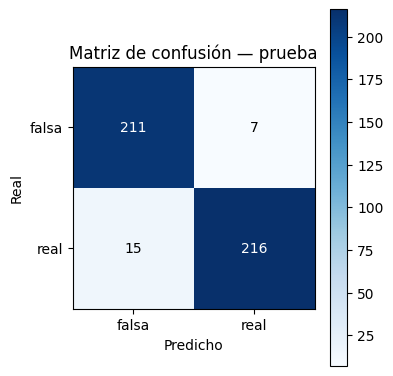

In [32]:
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xticks([0, 1]); ax.set_xticklabels(["falsa", "real"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["falsa", "real"])
ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — prueba")
plt.colorbar(im)
plt.tight_layout()
plt.savefig("matriz_confusion_bayesiana.png", dpi=150)
plt.show()


## §19 · Guardado de artefactos

In [34]:
DIR_SALIDA = "salida_bayesiana"
os.makedirs(DIR_SALIDA, exist_ok=True)

with open(os.path.join(DIR_SALIDA, "mejores_hiperparametros.json"), "w", encoding="utf-8") as f:
    json.dump({
        "mejores_hiperparametros": mejor_hp.values,
        "metricas_test": metricas_test,
        "modelo": MODELO,
        "modelo_sha": MODELO_SHA,
        "n_trials": CONFIG["n_trials"],
        "objetivo": CONFIG["objetivo"],
        "convergencia_n_repeticiones": N_REPETICIONES,

        "fecha": datetime.now().isoformat(),
    }, f, indent=2, ensure_ascii=False)

# Historial de todos los intentos de la busqueda (S14)
df_intentos.to_csv(os.path.join(DIR_SALIDA, "historial_intentos.csv"), index=False)

backbone_guardado = next(l for l in mejor_modelo.layers if hasattr(l, "save_pretrained"))
backbone_guardado.save_pretrained(os.path.join(DIR_SALIDA, "mejor_modelo"))
tokenizer.save_pretrained(os.path.join(DIR_SALIDA, "mejor_modelo"))


print(f"Guardado en ./{DIR_SALIDA}/:")
print("  - mejores_hiperparametros.json")
print("  - historial_intentos.csv")
print("  - historial_repeticiones_convergencia.csv")
print("  - mejor_modelo/ (pesos + tokenizador)")
print("  - matriz_confusion_bayesiana.png (§18)")


Guardado en ./salida_bayesiana/:
  - mejores_hiperparametros.json
  - historial_intentos.csv
  - historial_repeticiones_convergencia.csv
  - mejor_modelo/ (pesos + tokenizador)
  - matriz_confusion_bayesiana.png (§18)


## §20 · Resumen para el informe

Esta celda arma un párrafo con los números de esta corrida, para pegar
directamente en el informe.

In [35]:
print(f"""
Busqueda bayesiana con Keras Tuner ({CONFIG['n_trials']} intentos, objetivo
{CONFIG['objetivo']}) sobre RoBERTa-BNE ({MODELO}, commit {MODELO_SHA}), sin
congelar ninguna capa (0% de parametros congelados, igual que el articulo
de referencia). Mejores hiperparametros encontrados:
{json.dumps(mejor_hp.values, indent=2, ensure_ascii=False)}



Metricas sobre el conjunto de prueba (no tocado durante la busqueda):
{json.dumps(metricas_test, indent=2, ensure_ascii=False)}
""")



Busqueda bayesiana con Keras Tuner (8 intentos, objetivo
val_f1_macro) sobre RoBERTa-BNE (IsGarrido/roberta-base-bne, commit 3d54a71ddc029cc1f8dd604e3b7bc0da0e2f7cd9), sin
congelar ninguna capa (0% de parametros congelados, igual que el articulo
de referencia). Mejores hiperparametros encontrados:
{
  "learning_rate": 4.0983871094082436e-05,
  "dropout": 0.07258496356733739,
  "weight_decay": 0.008547485565344062,
  "batch_size": 8,
  "lr_reduce_factor": 0.3323028659735827,
  "lr_reduce_patience": 1,
  "early_stopping_patience": 3
}



Metricas sobre el conjunto de prueba (no tocado durante la busqueda):
{
  "accuracy": 0.951,
  "f1_macro": 0.951,
  "precision_macro": 0.9511,
  "recall_macro": 0.9515,
  "mcc": 0.9026,
  "precision_falsa": 0.9336,
  "recall_falsa": 0.9679,
  "f1_falsa": 0.9505
}

